In [110]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

In [124]:
#df = yf.download('TSLA',period='1y')
df = yf.download('VLK.AS',start='2024-01-01')

[*********************100%%**********************]  1 of 1 completed


In [148]:
def MACD(df):
    df['EMA3'] = df.Close.ewm(span=3).mean()
    df['EMA10'] = df.Close.ewm(span=10).mean()
    df['MACD'] = df.EMA3 - df.EMA10
    df['signal'] = df.MACD.ewm(span=9).mean()


In [149]:
MACD(df)

In [150]:
Buy, Sell = [], []
for i in range(2, len(df)):
    if df.MACD.iloc[i] > df.signal.iloc[i] and df.MACD.iloc[i-1] < df.signal.iloc[i-1]:
        Buy.append(i)
    elif df.MACD.iloc[i] < df.signal.iloc[i] and df.MACD.iloc[i-1] > df.signal.iloc[i-1]:
        Sell.append(i)

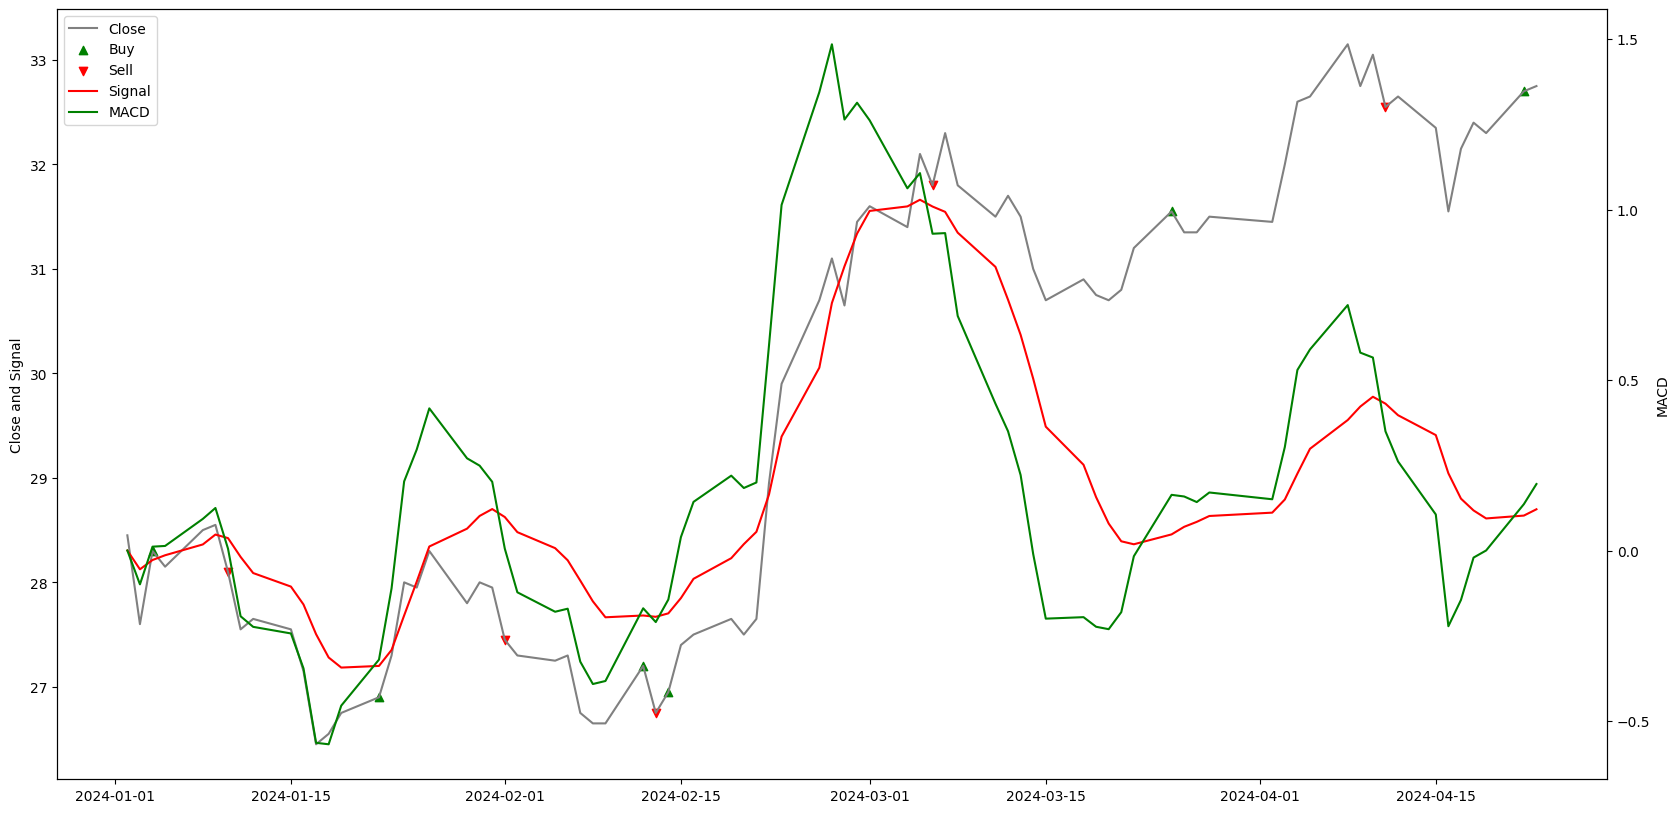

In [151]:
plt.figure(figsize=(20, 10))


# Primary y-axis
ax1 = plt.gca()  # Get current axis
ax1.plot(df['Close'], label='Close', color='grey')
ax1.scatter(df.iloc[Buy].index, df.iloc[Buy]['Close'], marker="^", color='green', label='Buy')
ax1.scatter(df.iloc[Sell].index, df.iloc[Sell]['Close'], marker="v", color='red', label='Sell')
ax1.set_ylabel('Close and Signal')

# Secondary y-axis
ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
ax2.plot(df['signal'], label='Signal', color='red')

ax2.plot(df['MACD'], label='MACD', color='green')
ax2.set_ylabel('MACD')

# Adding legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

In [153]:
Realbuys = [i+1 for i in Buy]
Realsells = [i+1 for i in Sell]

Buyprices = df.Open.iloc[Realbuys]
Sellprices = df.Open.iloc[Realsells]

In [154]:
if Sellprices.index[0] < Buyprices.index[0]:
    Sellprices = Sellprices.drop(Sellprices.index[0])
if Buyprices.index[-1] > Sellprices.index[-1]:
    Buyprices = Buyprices.drop(Buyprices.index[-1])

In [155]:
profitsrel = []

for i in range(len(Sellprices)):
    profitsrel.append((Sellprices[i] - Buyprices[i]) / Buyprices[i])

/var/folders/k3/7tqt3gf901qcwch_7zht4th00000gn/T/ipykernel_83854/2459428126.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  profitsrel.append((Sellprices[i] - Buyprices[i]) / Buyprices[i])


In [165]:
output = pd.DataFrame(profitsrel).mean()
print(f'{output.iloc[0]:.2f}%')

0.04%
